# Healthcare Risk Prediction for Insurance Companies

## Problem Statement
Insurance companies need to assess an applicant’s health risk to determine premiums and coverage plans. Traditional methods rely on historical data and manual assessments, which may not be accurate or scalable. This project aims to predict diabetes risk using machine learning models, enabling insurers to personalize policies based on predicted health conditions.

## Solution Overview
By leveraging the Behavioral Risk Factor Surveillance System (BRFSS) 2020 dataset, we develop and evaluate multiple machine learning models, including Random Forest, XGBoost, and a Neural Network, to predict diabetes risk. This enables insurance companies to make data-driven decisions for risk assessment and premium calculation.

## Dataset
I used the BRFSS 2020 dataset, which contains various health-related survey responses. The dataset includes categorical and numerical features, such as education level, income, BMI, and physical health indicators.

## Code Breakdown

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

**Importing Required Libraries**
* Pandas & NumPy: Used for handling tabular data.
* Seaborn & Matplotlib: Used for visualizations.
* Scikit-learn: Provides functions for data preprocessing, model training, and evaluation.
* XGBoost: A gradient-boosting model for better predictive performance.
* PyTorch: Used to build a deep learning model.


In [2]:
def load_and_clean_brfss_data(file_path):
    dtypes = {
        'DIABETE4': 'int8',  
        'MARITAL': 'category',
        'EDUCA': 'category',
        'INCOME2': 'float32',
        '_BMI5': 'float32',
        'BIRTHSEX': 'category',
        '_RACE': 'category',
        '_STATE': 'category',
        'VETERAN3': 'category',
        'EMPLOY1': 'category',
        '_RFHLTH': 'int8',
        '_PHYS14D': 'int8',
        '_MENT14D': 'int8',
        'CHECKUP1': 'int8',
        'HLTHPLN1': 'category'
    }
    df = pd.read_csv(file_path, usecols=dtypes.keys(), low_memory=False)
    
    # Replace missing codes with NaN
    missing_codes = {7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan}
    df = df.replace(missing_codes)

    # Convert DIABETE4 (target variable) to binary
    df['DIABETE4'] = df['DIABETE4'].map({1: 1, 2: 0, 3: 0, 4: 0})
    df = df.dropna(subset=['DIABETE4'])

    # Fill missing values
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    categorical_cols = df.select_dtypes(include=['category', 'object']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    return df


**Data Loading & Cleaning**

* clean, and preprocess the dataset by handling missing values and converting categorical features.


In [3]:
def visualize_data(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df['_BMI5'], y=df['_PHYS14D'], hue=df['DIABETE4'])
    plt.title('Scatter Plot of BMI vs Physical Health')
    plt.xlabel('BMI')
    plt.ylabel('Physical Health Issues (Days)')
    plt.legend(title='Diabetes')
    plt.show()

    plt.figure(figsize=(8, 6))
    df['DIABETE4'].value_counts().plot(kind='bar', color=['blue', 'orange'])
    plt.title('Diabetes Distribution')
    plt.xlabel('Diabetes (0: No, 1: Yes)')
    plt.ylabel('Count')
    plt.show()

    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Features')
    plt.show()


**Data Visualization**
* The target variable (DIABETE4) is mapped to binary values:
* 1 → diabetic
* 2, 3, 4 → non-diabetic

* Drops rows where DIABETE4 is missing

In [4]:
def preprocess_data(df):
    categorical_cols = df.select_dtypes(include=['category']).columns
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    return df_scaled

* Numerical columns → Missing values are filled with the median.
* Categorical columns → Missing values are filled with the mode (most frequent value).

In [5]:
def visualize_data(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df['_BMI5'], y=df['_PHYS14D'], hue=df['DIABETE4'])
    plt.title('Scatter Plot of BMI vs Physical Health')
    plt.xlabel('BMI')
    plt.ylabel('Physical Health Issues (Days)')
    plt.legend(title='Diabetes')
    plt.show()

    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Features')
    plt.show()


* Scatter plot to visualize the relationship between BMI and physical health issues.
* Color-coded by diabetes status.
* Bar chart to show the distribution of diabetic vs. non-diabetic individuals.
* Correlation heatmap to analyze feature relationships.

In [53]:
def train_model(model_type, X_train, X_test, y_train, y_test):
    if model_type == "rf":
        model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    elif model_type == "xgb":
        model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{model_type.upper()} Results:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Confusion Matrix - {model_type.upper()}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return model, y_pred


Defines Random Forest and XGBoost classifiers with hyperparameters.

In [54]:
class BRFSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


Convert the dataset into a PyTorch-friendly format for training a neural network.

In [55]:
class DiabetesPredictor(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesPredictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)


* A 3-layer Neural Network using ReLU activations and Dropout for regularization.
* The final layer uses Sigmoid for binary classification.

In [56]:
def train_neural_network(X_train, X_test, y_train, y_test):
    input_dim = X_train.shape[1]
    batch_size = 256
    epochs = 5

    train_dataset = BRFSSDataset(X_train.values, y_train.values)
    test_dataset = BRFSSDataset(X_test.values, y_test.values)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DiabetesPredictor(input_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch.view(-1, 1))
            loss.backward()
            optimizer.step()

    # Evaluate the model
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            y_pred_list.append(y_pred.cpu().numpy())

    y_pred = np.concatenate(y_pred_list).flatten()
    y_pred = (y_pred > 0.5).astype(int)

    print("\nNeural Network Results:")
    print(classification_report(y_test, y_pred))


Trains the model using binary cross-entropy loss and Adam optimizer.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


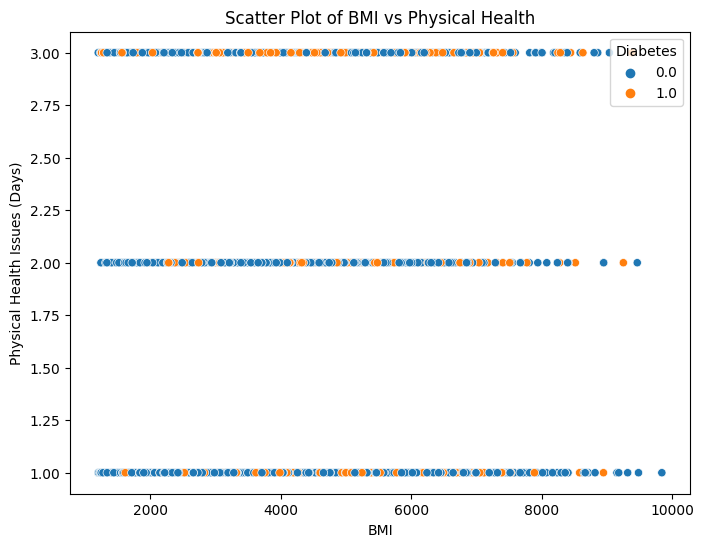

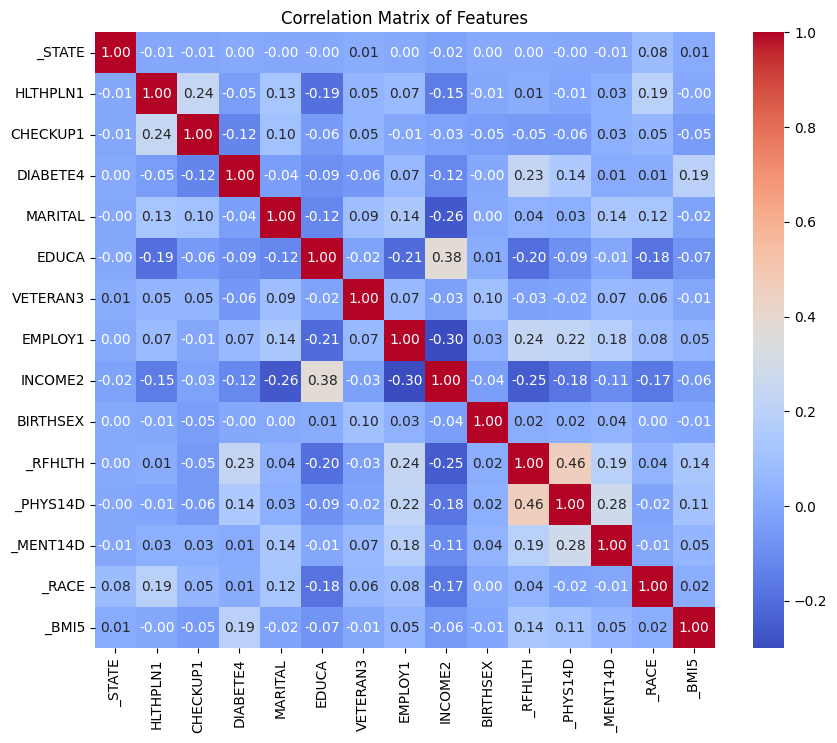


RF Results:
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93     69811
         1.0       0.64      0.01      0.02     10418

    accuracy                           0.87     80229
   macro avg       0.75      0.50      0.47     80229
weighted avg       0.84      0.87      0.81     80229



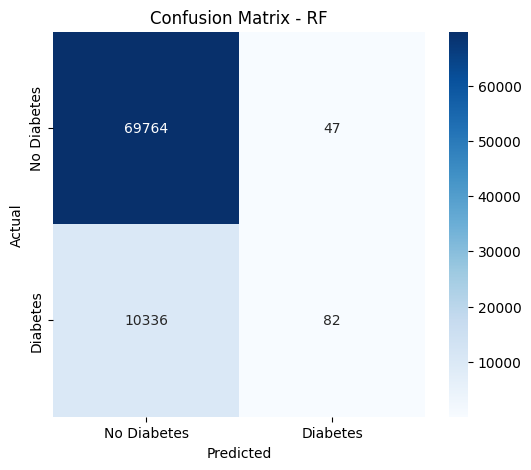


XGB Results:
              precision    recall  f1-score   support

         0.0       0.88      0.99      0.93     69811
         1.0       0.52      0.06      0.11     10418

    accuracy                           0.87     80229
   macro avg       0.70      0.53      0.52     80229
weighted avg       0.83      0.87      0.82     80229



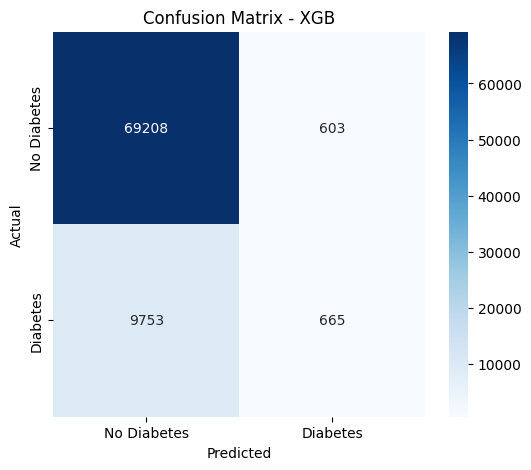


Neural Network Results:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93     69811
         1.0       0.53      0.04      0.08     10418

    accuracy                           0.87     80229
   macro avg       0.70      0.52      0.51     80229
weighted avg       0.83      0.87      0.82     80229



In [57]:
def main():
    df = load_and_clean_brfss_data('/kaggle/input/brfss-2020-survey-data/brfss2020.csv')
    visualize_data(df)
    y = df.pop('DIABETE4')
    X = preprocess_data(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_model("rf", X_train, X_test, y_train, y_test)
    train_model("xgb", X_train, X_test, y_train, y_test)
    train_neural_network(X_train, X_test, y_train, y_test)

if __name__ == "__main__":
    main()


Runs data processing, model training, and evaluation.

* Precision: The ratio of correctly predicted positive observations to the total predicted positive observations.

* Recall: The ratio of correctly predicted positive observations to all actual positive observations.

* F1-score: The harmonic mean of precision and recall, providing a single score that balances both metrics.

* Support: The number of actual occurrences of the class in the specified dataset.

## Conclusion
* This project demonstrates the application of machine learning for healthcare risk prediction, 
* aiding insurance companies in assessing diabetes risk and customizing insurance policies accordingly. 
* Future improvements may include feature engineering and ensemble learning.